In [1]:
%load_ext watermark


In [2]:
import os

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-23T17:13:13.991451+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-23-d2h-memcpy-diagnostics")
teeplot_subdir


'2026-03-23-d2h-memcpy-diagnostics'

## Fetch Data


In [5]:
url = "https://github.com/user-attachments/files/26186490/bookends.csv"
df = pd.read_csv(url)
print(f"{len(df)} mismatched bookend records")
df.head()


5722 mismatched bookend records


,data_hex,layer,layer_T,position
0,12e56402bb333a590001d3821406bdb9928db58b20b2e4...,1,1,309593
1,12e57802000000000001d2ec34ff658cdf668320795b06...,1,1,309598
2,12e58c02b9c608310001d58480c342799944d751680736...,1,1,309603
3,12e5a002000000000001d559ebdaccd9b14657657702a1...,1,1,309608
4,12e5b402baaff4c70001d5243d27095d96a5574b40212b...,1,1,309613


## Parse Bookends and Classify Parity Errors


In [6]:
df["start_bookend"] = df["data_hex"].str[:8].apply(int, base=16)
df["end_bookend"] = df["data_hex"].str[-8:].apply(int, base=16)
df["diff"] = df["end_bookend"] - df["start_bookend"]

df["parity_error"] = np.where(
    df["diff"] == 512,
    "+1 parity",
    np.where(df["diff"] == -512, "-1 parity", "other"),
)
print(df["parity_error"].value_counts())
df.head()


parity_error
+1 parity    3426
-1 parity    2296
Name: count, dtype: int64


,data_hex,layer,layer_T,position,start_bookend,end_bookend,diff,parity_error
0,12e56402bb333a590001d3821406bdb9928db58b20b2e4...,1,1,309593,317023234,317023746,512,+1 parity
1,12e57802000000000001d2ec34ff658cdf668320795b06...,1,1,309598,317028354,317028866,512,+1 parity
2,12e58c02b9c608310001d58480c342799944d751680736...,1,1,309603,317033474,317033986,512,+1 parity
3,12e5a002000000000001d559ebdaccd9b14657657702a1...,1,1,309608,317038594,317039106,512,+1 parity
4,12e5b402baaff4c70001d5243d27095d96a5574b40212b...,1,1,309613,317043714,317044226,512,+1 parity


## Spatial Coordinates


In [7]:
nRow = 1170
nCol = 755
df["x"] = df["position"] // nCol  # row
df["y"] = df["position"] % nCol  # column

print(f"Row range: {df['x'].min()}--{df['x'].max()}")
print(f"Col range: {df['y'].min()}--{df['y'].max()}")


Row range: 410--410
Col range: 0--248


## Plot 1 --- Spatial Distribution


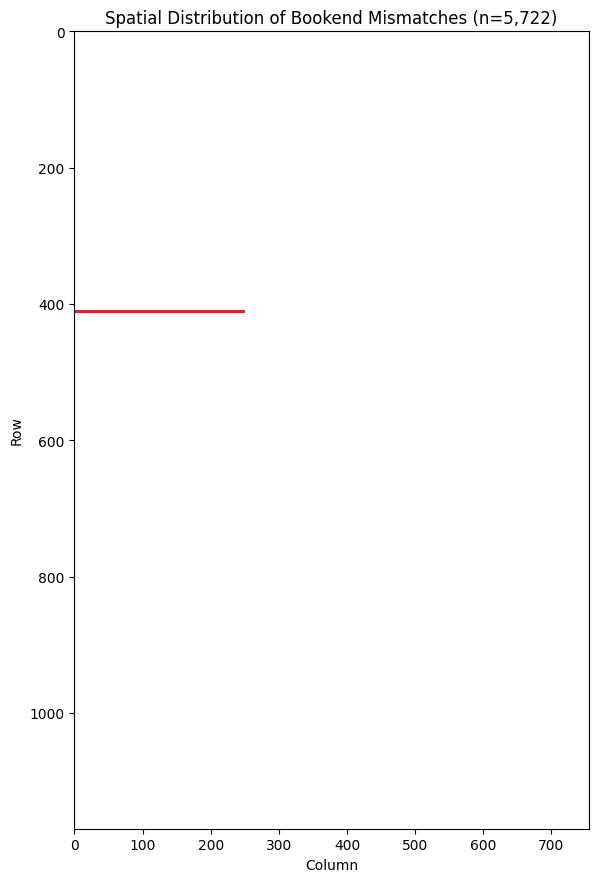

In [8]:
fig, ax = plt.subplots(figsize=(6, 9))
ax.scatter(df["y"], df["x"], s=1, alpha=0.4, color="tab:red")
ax.set_xlim(0, nCol)
ax.set_ylim(nRow, 0)  # invert so row 0 is at top
ax.set_aspect("equal")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_title(f"Spatial Distribution of Bookend Mismatches (n={len(df):,})")
fig.tight_layout()
plt.show()


## Plot 2 --- Temporal Distribution Across Layers


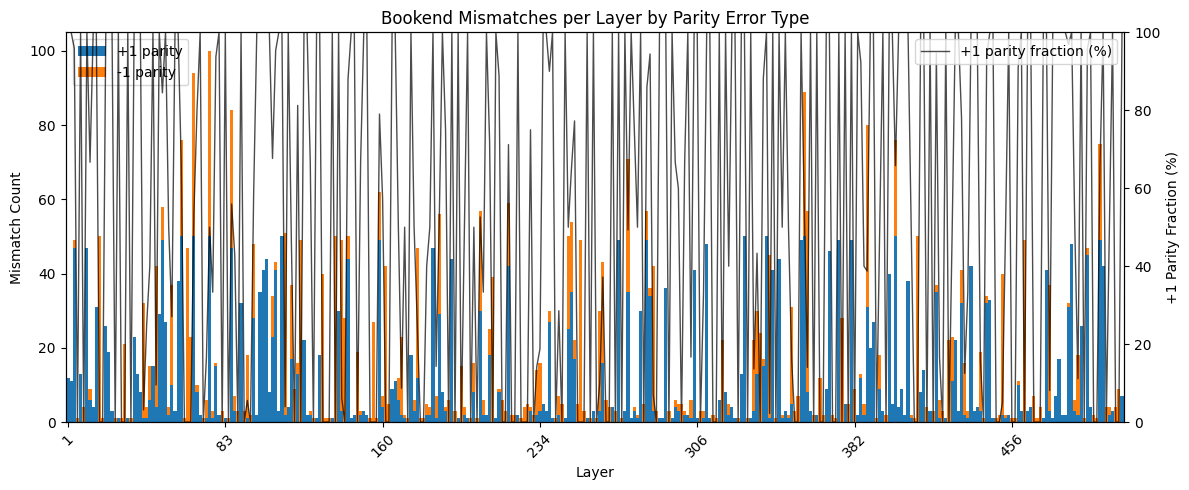

In [9]:
counts = df.groupby(["layer", "parity_error"]).size().unstack(fill_value=0)
# ensure both columns exist
for col in ["+1 parity", "-1 parity"]:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[["+1 parity", "-1 parity"]]

total_per_layer = counts.sum(axis=1)
frac_plus1 = (counts["+1 parity"] / total_per_layer * 100).fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 5))
counts.plot.bar(
    stacked=True,
    ax=ax1,
    color=["tab:blue", "tab:orange"],
    width=1.0,
    edgecolor="none",
)
ax1.set_xlabel("Layer")
ax1.set_ylabel("Mismatch Count")
ax1.set_title("Bookend Mismatches per Layer by Parity Error Type")
ax1.legend(loc="upper left")

# thin out x tick labels
tick_spacing = 50
tick_positions = range(0, len(counts), tick_spacing)
ax1.set_xticks(list(tick_positions))
ax1.set_xticklabels([counts.index[i] for i in tick_positions], rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    range(len(frac_plus1)),
    frac_plus1.values,
    color="black",
    linewidth=1,
    alpha=0.7,
    label="+1 parity fraction (%)",
)
ax2.set_ylabel("+1 Parity Fraction (%)")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()
